# Efficiency Bubble Chart

Bubble charts for efficiency analysis with MAE vs parameters and FLOPs as bubble size.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["font.family"] = "Georgia"
# Example data: model efficiency comparison
model_names = ["Transformer", "SAITS", "OFA", "LLM4HRS", "MoE4MRS"]

# MAE values for different tasks
mae_avg = [3.2377, 3.3447, 2.9463, 2.0874, 1.5298]
mae_cha = [1.9024, 1.7316, 1.5353, 1.4628, 1.3941]
mae_par = [5.2117, 6.0660, 6.3109, 3.6460, 3.5003]
mae_sst = [2.5991, 2.2755, 2.7578, 1.0326, 0.6944]

# Model parameters (in millions)
params = [12.2, 8.4, 2.6, 10.6, 9.4/3]

# FLOPs values (in GFLOPs)
flops = [14.7, 24.2, 5.2, 43.7, 78.4/3]

# Color scheme
colors = ['#3288bd', '#66c2a5', '#abdda4', '#e6f598', '#fee08b']
# colors = ['#3288bd', '#66c2a5', '#abdda4', '#e6f598', '#fee08b', '#fdae61', '#f46d43', '#d53e4f']

## Single Efficiency Bubble Chart


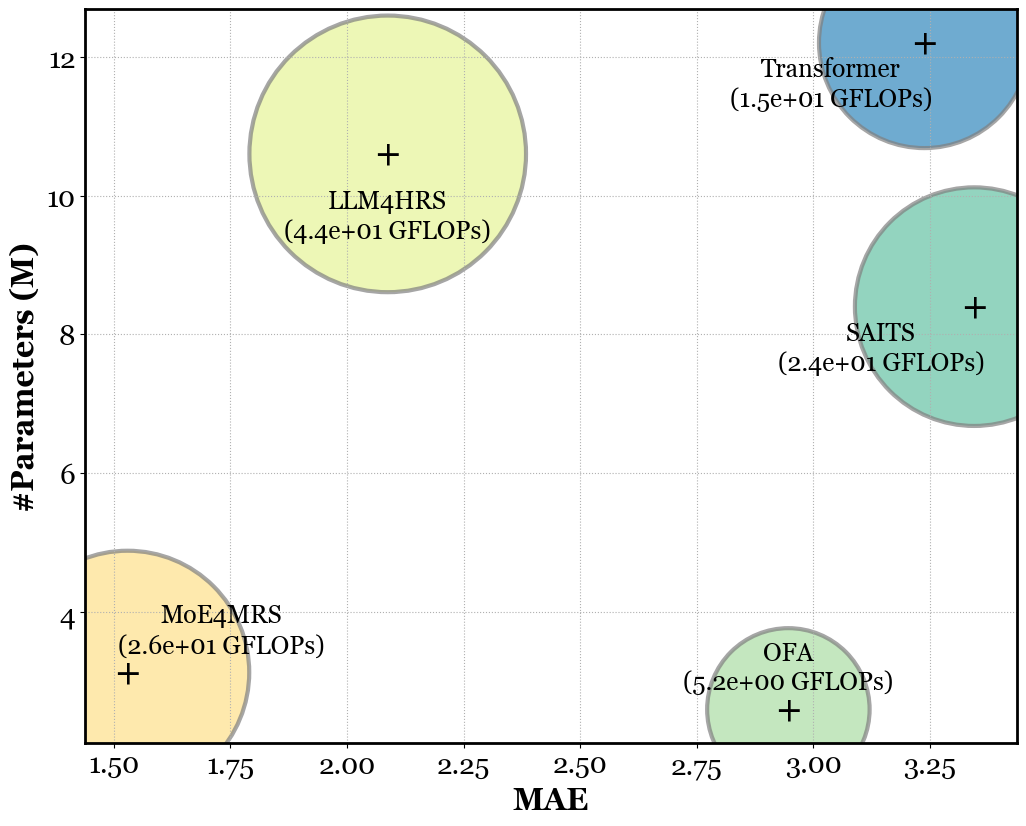

In [4]:
def plot_efficiency_bubble(x_values, y_values, sizes, labels, flops_values=None, 
                          colors=None, figsize=(10, 8), font_size=20, 
                          linewidth=3, alpha=0.7, center_marker='+',
                          label_offsets=None, show_grid=True):
    """
    Plot efficiency bubble chart.
    
    Parameters:
    -----------
    x_values : array-like
        X-axis values (e.g., MAE)
    y_values : array-like
        Y-axis values (e.g., parameters)
    sizes : array-like
        Bubble sizes (proportional to FLOPs or other metrics)
    labels : list
        Data point labels (model names)
    flops_values : array-like, optional
        FLOPs values for labeling
    colors : list, optional
        Color list for bubbles
    figsize : tuple, default=(10, 8)
        Figure size
    font_size : int, default=20
        Font size for labels
    linewidth : int, default=3
        Bubble edge line width
    alpha : float, default=0.7
        Bubble transparency
    center_marker : str, default='+'
        Marker at bubble center
    label_offsets : list of tuples, optional
        Custom offsets for text labels [(dx1, dy1), ...]
    show_grid : bool, default=True
        Show grid lines
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    """
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Default colors if not provided
    if colors is None:
        colors = plt.cm.Set3(np.linspace(0, 1, len(x_values)))
    
    # Create scatter plot
    ax.scatter(x_values, y_values, s=sizes, edgecolors='grey', 
               linewidth=linewidth, alpha=alpha, c=colors)
    
    # Add center markers
    for i in range(len(x_values)):
        ax.text(x_values[i], y_values[i], center_marker, 
                fontsize=font_size*1.5, ha='center', va='center', 
                color='black')
    
    # Add text labels
    for i, label in enumerate(labels):
        # Default offsets
        if label_offsets is None or i >= len(label_offsets):
            dx, dy = 0, 0
        else:
            dx, dy = label_offsets[i]
        
        # Create label text
        if flops_values is not None:
            label_text = f"{label}\n({flops_values[i]:.1e} GFLOPs)"
        else:
            label_text = label
        
        ax.text(x_values[i] + dx, y_values[i] + dy, label_text,
                fontsize=font_size*0.9, ha='center', va='top')
    
    # Formatting
    ax.tick_params(axis='both', labelsize=font_size)
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    
    if show_grid:
        ax.grid(True, linestyle=":")
    
    plt.tight_layout()
    return fig

# Calculate bubble sizes from FLOPs (size ∝ sqrt(FLOPs))
bubble_sizes = (np.array(flops) ** 0.5) * 6000

# Plot single bubble chart
fig = plot_efficiency_bubble(
    x_values=mae_avg,
    y_values=params,
    sizes=bubble_sizes,
    labels=model_names,
    flops_values=flops,
    colors=colors,
    label_offsets=[(-0.2, -0.2), (-0.2, -0.2), (0, 1.0), (0, -0.5), (0.2, 1.0)]
)

plt.xlabel("MAE", fontsize=22, fontweight='bold')
plt.ylabel("#Parameters (M)", fontsize=22, fontweight='bold')
plt.show()

## Multi-panel Efficiency Comparison


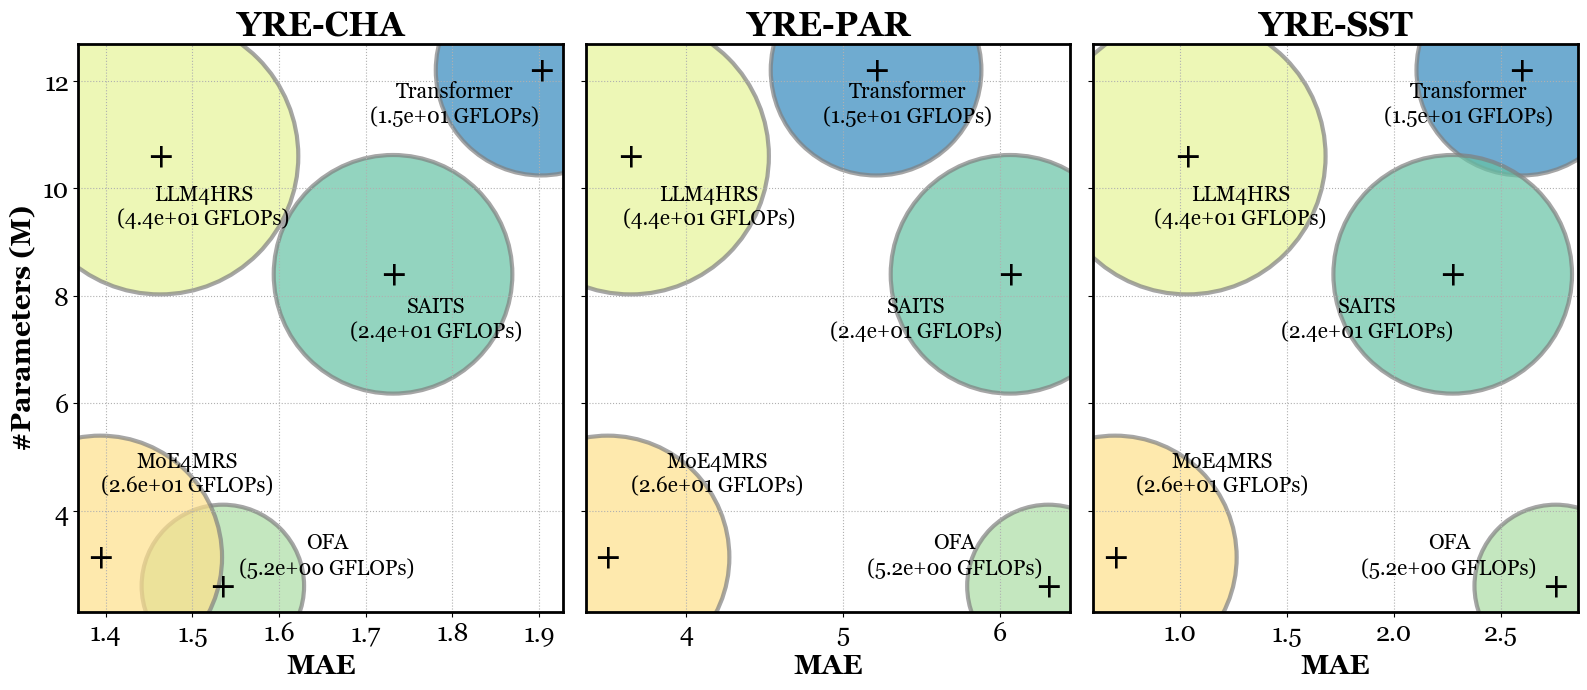

In [5]:
def plot_efficiency_subplots(x_lists, y_values, sizes, labels, flops_values, 
                            colors=None, titles=None, figsize=(16, 7), 
                            font_size=20, linewidth=3, alpha=0.7,
                            center_marker='+', label_offsets_list=None,
                            sharey=True, show_grid=True):
    """
    Plot multiple efficiency bubble charts as subplots.
    
    Parameters:
    -----------
    x_lists : list of array-like
        List of X-axis values for each subplot
    y_values : array-like
        Y-axis values (same for all subplots)
    sizes : array-like
        Bubble sizes (same for all subplots)
    labels : list
        Data point labels (model names)
    flops_values : array-like
        FLOPs values for labeling
    colors : list, optional
        Color list for bubbles
    titles : list, optional
        Subplot titles
    figsize : tuple, default=(16, 7)
        Figure size
    font_size : int, default=20
        Font size for labels
    linewidth : int, default=3
        Bubble edge line width
    alpha : float, default=0.7
        Bubble transparency
    center_marker : str, default='+'
        Marker at bubble center
    label_offsets_list : list of lists, optional
        Custom offsets for each subplot [[(dx1, dy1), ...], ...]
    sharey : bool, default=True
        Share Y-axis across subplots
    show_grid : bool, default=True
        Show grid lines
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    axes : numpy.ndarray
        Array of axes objects
    """
    
    n_subplots = len(x_lists)
    
    # Default titles if not provided
    if titles is None:
        titles = [f"Task {i+1}" for i in range(n_subplots)]
    
    # Default colors if not provided
    if colors is None:
        colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))
    
    fig, axes = plt.subplots(1, n_subplots, figsize=figsize, sharey=sharey)
    
    # Handle single subplot case
    if n_subplots == 1:
        axes = [axes]
    
    for idx, ax in enumerate(axes):
        x_values = x_lists[idx]
        
        # Create scatter plot
        ax.scatter(x_values, y_values, s=sizes, edgecolors='grey',
                   linewidth=linewidth, alpha=alpha, c=colors)
        
        # Add center markers
        for i in range(len(x_values)):
            ax.text(x_values[i], y_values[i], center_marker,
                    fontsize=font_size*1.5, ha='center', va='center',
                    color='black')
        
        # Add text labels
        for i, label in enumerate(labels):
            # Get offsets for this subplot
            if label_offsets_list is not None and idx < len(label_offsets_list):
                offsets = label_offsets_list[idx]
                if i < len(offsets):
                    dx, dy = offsets[i]
                else:
                    dx, dy = 0, 0
            else:
                dx, dy = 0, 0
            
            # Create label text
            label_text = f"{label}\n({flops_values[i]:.1e} GFLOPs)"
            
            ax.text(x_values[i] + dx, y_values[i] + dy, label_text,
                    fontsize=font_size*0.75, ha='center', va='top')
        
        # Formatting
        ax.set_title(titles[idx], fontsize=font_size*1.2, fontweight='bold')
        ax.set_xlabel("MAE", fontsize=font_size, fontweight='bold')
        ax.tick_params(axis='both', labelsize=font_size*0.9)
        
        for spine in ax.spines.values():
            spine.set_linewidth(2)
            spine.set_edgecolor('black')
        
        if show_grid:
            ax.grid(True, linestyle=":")
    
    # Set Y label for first subplot
    axes[0].set_ylabel("#Parameters (M)", fontsize=font_size, fontweight='bold')
    
    plt.tight_layout()
    return fig, axes

# Prepare data for multi-panel plot
x_lists = [mae_cha, mae_par, mae_sst]
subplot_titles = ["YRE-CHA", "YRE-PAR", "YRE-SST"]

# Custom offsets for each subplot
offsets_list = [
    [(-0.1, -0.2), (0.05, -0.4), (0.12, 1.0), (0.05, -0.5), (0.1, 2.0)],
    [(0.2, -0.2), (-0.6, -0.4), (-0.6, 1.0), (0.5, -0.5), (0.7, 2.0)],
    [(-0.25, -0.2), (-0.4, -0.4), (-0.5, 1.0), (0.25, -0.5), (0.5, 2.0)]
]

# Plot multi-panel comparison
fig, axes = plot_efficiency_subplots(
    x_lists=x_lists,
    y_values=params,
    sizes=bubble_sizes,
    labels=model_names,
    flops_values=flops,
    colors=colors,
    titles=subplot_titles,
    label_offsets_list=offsets_list
)

plt.show()